In [ ]:
pip install pandas scikit-learn xgboost

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
from google.colab import files



In [ ]:
# Upload the file
uploaded = files.upload()

# Load the dataset
file_name = next(iter(uploaded))  # Get the uploaded file name
data = pd.read_csv(file_name)


Saving 10 pipe dataset.csv to 10 pipe dataset.csv


In [ ]:
# Display first few rows of the dataset
print("Dataset Preview:")
print(data.head())

Dataset Preview:
   Time  Day_of_week  Age_band_of_driver  Sex_of_driver  Educational_level  \
0   420            1                   0              1                  0   
1   420            1                   1              1                  4   
2   420            1                   0              1                  4   
3   594            3                   0              1                  4   
4   594            3                   0              1                  4   

   Vehicle_driver_relation  Driving_experience  Type_of_vehicle  \
0                        0                   0                0   
1                        0                   3               11   
2                        0                   0                5   
3                        0                   2               11   
4                        0                   1                0   

   Owner_of_vehicle  Service_year_of_vehicle  ...  Vehicle_movement  \
0                 3                     

In [ ]:
print("\nDataset Info:")
print(data.info())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12316 entries, 0 to 12315
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   Time                         12316 non-null  int64
 1   Day_of_week                  12316 non-null  int64
 2   Age_band_of_driver           12316 non-null  int64
 3   Sex_of_driver                12316 non-null  int64
 4   Educational_level            12316 non-null  int64
 5   Vehicle_driver_relation      12316 non-null  int64
 6   Driving_experience           12316 non-null  int64
 7   Type_of_vehicle              12316 non-null  int64
 8   Owner_of_vehicle             12316 non-null  int64
 9   Service_year_of_vehicle      12316 non-null  int64
 10  Defect_of_vehicle            12316 non-null  int64
 11  Area_accident_occured        12316 non-null  int64
 12  Lanes_or_Medians             12316 non-null  int64
 13  Road_allignment              12

In [ ]:
# Display summary statistics
print("\nSummary Statistics:")
print(data.describe())


Summary Statistics:
               Time   Day_of_week  Age_band_of_driver  Sex_of_driver  \
count  12316.000000  12316.000000        12316.000000   12316.000000   
mean     504.737090      2.980513            1.292952       0.957535   
std      293.164211      2.059712            1.337520       0.263767   
min        0.000000      0.000000            0.000000       0.000000   
25%      280.000000      1.000000            0.000000       1.000000   
50%      463.000000      3.000000            1.000000       1.000000   
75%      711.250000      5.000000            2.000000       1.000000   
max     1073.000000      6.000000            4.000000       2.000000   

       Educational_level  Vehicle_driver_relation  Driving_experience  \
count       12316.000000             12316.000000        12316.000000   
mean            3.208347                 0.333793            1.943732   
std             1.361538                 0.741375            1.236146   
min             0.000000              

<ipython-input-20-45acd17e91fd>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Accident_severity', data=data, palette='viridis')


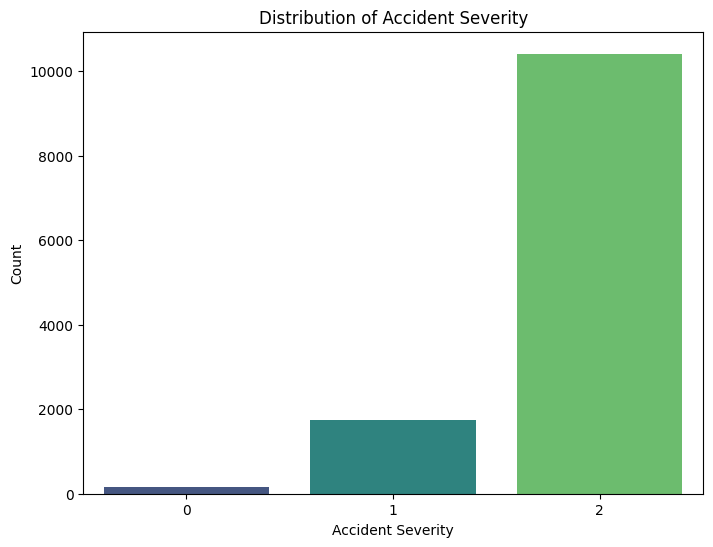

In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(x='Accident_severity', data=data, palette='viridis')
plt.title('Distribution of Accident Severity')
plt.xlabel('Accident Severity')
plt.ylabel('Count')
plt.show()

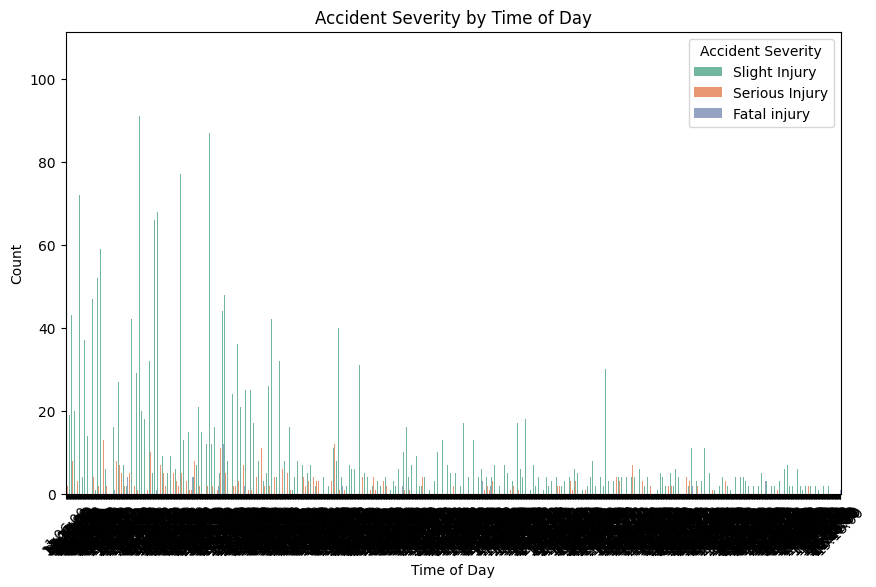

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Time', hue='Accident_severity', data=data, palette='Set2')
plt.title('Accident Severity by Time of Day')
plt.xlabel('Time of Day')
plt.ylabel('Count')
plt.legend(title='Accident Severity')
plt.xticks(rotation=45)
plt.show()

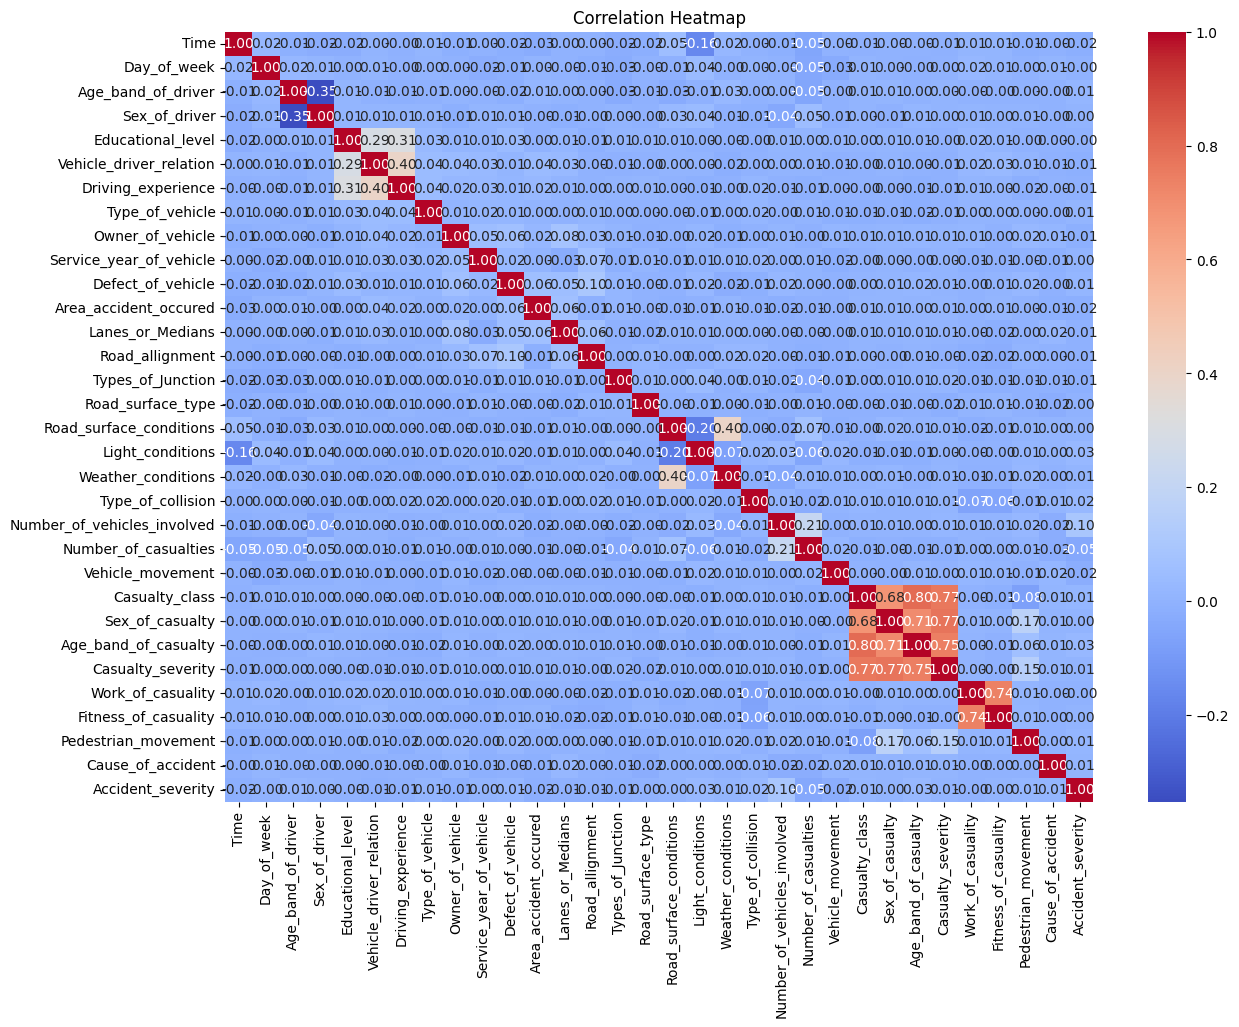

In [ ]:
data_encoded = data.copy()
for col in data_encoded.select_dtypes(include=['object']).columns:
    data_encoded[col] = LabelEncoder().fit_transform(data_encoded[col])

plt.figure(figsize=(14, 10))
sns.heatmap(data_encoded.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

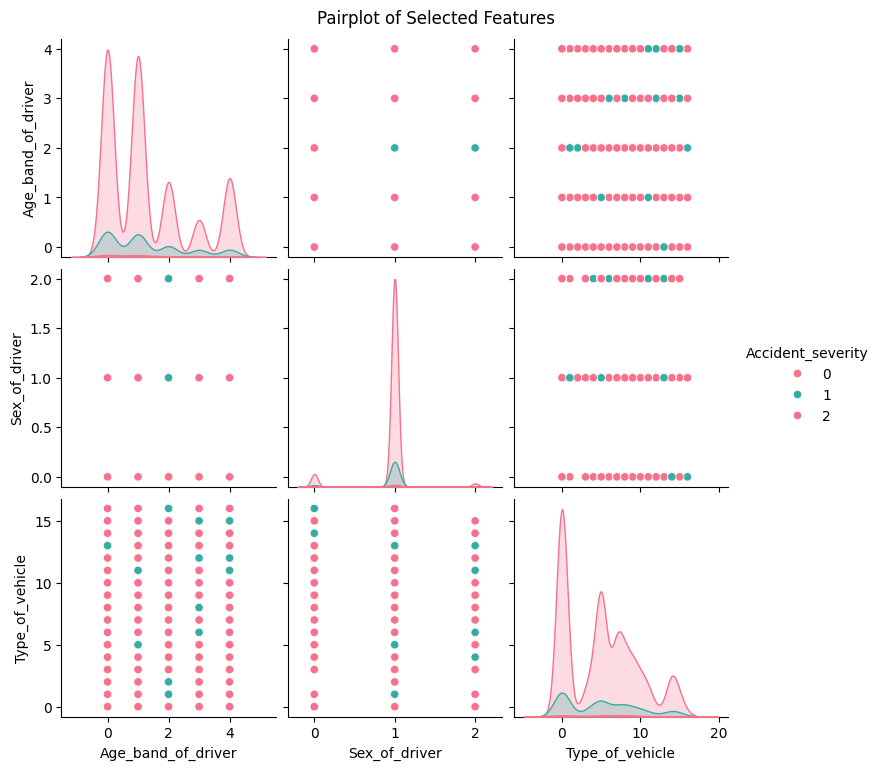

In [ ]:
selected_features = ['Age_band_of_driver', 'Sex_of_driver', 'Type_of_vehicle', 'Accident_severity']
sns.pairplot(data[selected_features], hue='Accident_severity', palette='husl')
plt.suptitle('Pairplot of Selected Features', y=1.02)
plt.show()

In [ ]:
# Impute missing values for categorical columns with the most frequent value
categorical_cols = data.select_dtypes(include=['object']).columns
imputer = SimpleImputer(strategy='most_frequent')
data[categorical_cols] = imputer.fit_transform(data[categorical_cols])

# Encode categorical variables using LabelEncoder
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    label_encoders[col] = le

# Define target and features
X = data.drop(columns=['Accident_severity'])
y = data['Accident_severity']

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [ ]:
# Initialize the XGBoost classifier
model = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')

# Train the model
model.fit(X_train, y_train)


/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [15:26:04] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, objective='multi:softprob', ...)

In [ ]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print("Classification Report:\n", report)


Accuracy: 0.849025974025974
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.13      0.23        31
           1       0.52      0.08      0.14       349
           2       0.86      0.99      0.92      2084

    accuracy                           0.85      2464
   macro avg       0.79      0.40      0.43      2464
weighted avg       0.81      0.85      0.80      2464



In [ ]:
# Save and download the model (optional)
joblib.dump(model, 'xgboost_accident_severity_model.pkl')
files.download('xgboost_accident_severity_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
def safe_transform(label_encoder, value):
    try:
        return label_encoder.transform([value])[0]
    except ValueError:
        # Handle unseen label
        return -1  # or map to a default/unknown category

def predict_accident_severity(user_input):
    # Preprocess the input in the same way as the training data
    input_df = pd.DataFrame([user_input], columns=X.columns)

    for col in categorical_cols:
        if col in input_df.columns:
            if col in label_encoders:
                # Use safe_transform to handle unseen labels
                input_df[col] = input_df[col].apply(lambda x: safe_transform(label_encoders[col], x))

    # Predict using the trained model
    prediction = model.predict(input_df)
    severity = label_encoders['Accident_severity'].inverse_transform(prediction)

    return severity[0]

In [ ]:
user_input_example = {
    'Time': 'Night',  # Example value, replace with actual
    'Day_of_week': 'Friday',  # Example value, replace with actual
    'Age_band_of_driver': '31-50',  # Example value, replace with actual
    'Sex_of_driver': 'Female',  # Example value, replace with actual
    'Educational_level': 'Primary',  # Example value, replace with actual
    'Vehicle_driver_relation': 'Employee',  # Example value, replace with actual
    'Driving_experience': '5-10yr',  # Example value, replace with actual
    'Type_of_vehicle': 'Lorry (41-50Q)',  # Example value, replace with actual
    'Owner_of_vehicle': 'Governmental',  # Example value, replace with actual
    'Service_year_of_vehicle': 'Above 10yr',  # Example value, replace with actual
    'Defect_of_vehicle': 'No defect',  # Example value, replace with actual
    'Area_accident_occured': 'Residential area',  # Example value, replace with actual
    'Lanes_or_Medians': 'Double carriageway (median)',  # Example value, replace with actual
    'Road_allignment': 'Straight road',  # Example value, replace with actual
    'Types_of_Junction': 'T Junction',  # Example value, replace with actual
    'Road_surface_type': 'Asphalt roads',  # Example value, replace with actual
    'Road_surface_conditions': 'Dry',  # Example value, replace with actual
    'Light_conditions': 'Darkness - lights lit',  # Example value, replace with actual
    'Weather_conditions': 'Clear',  # Example value, replace with actual
    'Type_of_collision': 'Vehicle with pedestrian',  # Example value, replace with actual
    'Number_of_vehicles_involved': 1,  # Example value, replace with actual
    'Number_of_casualties': 1,  # Example value, replace with actual
    'Vehicle_movement': 'Going straight',  # Example value, replace with actual
    'Casualty_class': 'Pedestrian',  # Example value, replace with actual
    'Sex_of_casualty': 'Female',  # Example value, replace with actual
    'Age_band_of_casualty': 'Under 18',  # Example value, replace with actual
    'Casualty_severity': '3',  # Example value, replace with actual
    'Work_of_casuality': 'Student',  # Example value, replace with actual
    'Fitness_of_casuality': 'Normal',  # Example value, replace with actual
    'Pedestrian_movement': 'Crossing from nearside - masked by parked or stationary vehicle',  # Example value, replace with actual
    'Cause_of_accident': 'Over speeding',  # Example value, replace with actual
}





In [ ]:
# Predict using the example input
predicted_severity = predict_accident_severity(user_input_example)
print(f"Predicted Accident Severity: {predicted_severity}")

Predicted Accident Severity: Slight Injury
